# Manager Development ROI & High-Potential Manager Identification

## Key Questions
1. Does manager training actually improve effectiveness?
2. What is the ROI of investing in manager development?
3. Which managers are high-potential leadership candidates?
4. Who needs intensive coaching vs. standard development?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
managers = pd.read_csv('../data/managers.csv')
training = pd.read_csv('../data/manager_training.csv')
team_performance = pd.read_csv('../data/team_performance.csv')
promotions = pd.read_csv('../data/promotions_from_team.csv')
team_retention = pd.read_csv('../data/team_retention.csv')

print(f"Loaded {len(managers)} managers")
print(f"Loaded {len(training)} training records")
print(f"Loaded {len(team_performance)} team performance records")
print(f"Loaded {len(promotions)} promotion records")

Loaded 45 managers
Loaded 107 training records
Loaded 135 team performance records
Loaded 135 promotion records


## 1. Manager Training Effectiveness

**Question**: Does training improve manager effectiveness scores?

Let's analyze pre/post training effectiveness changes.

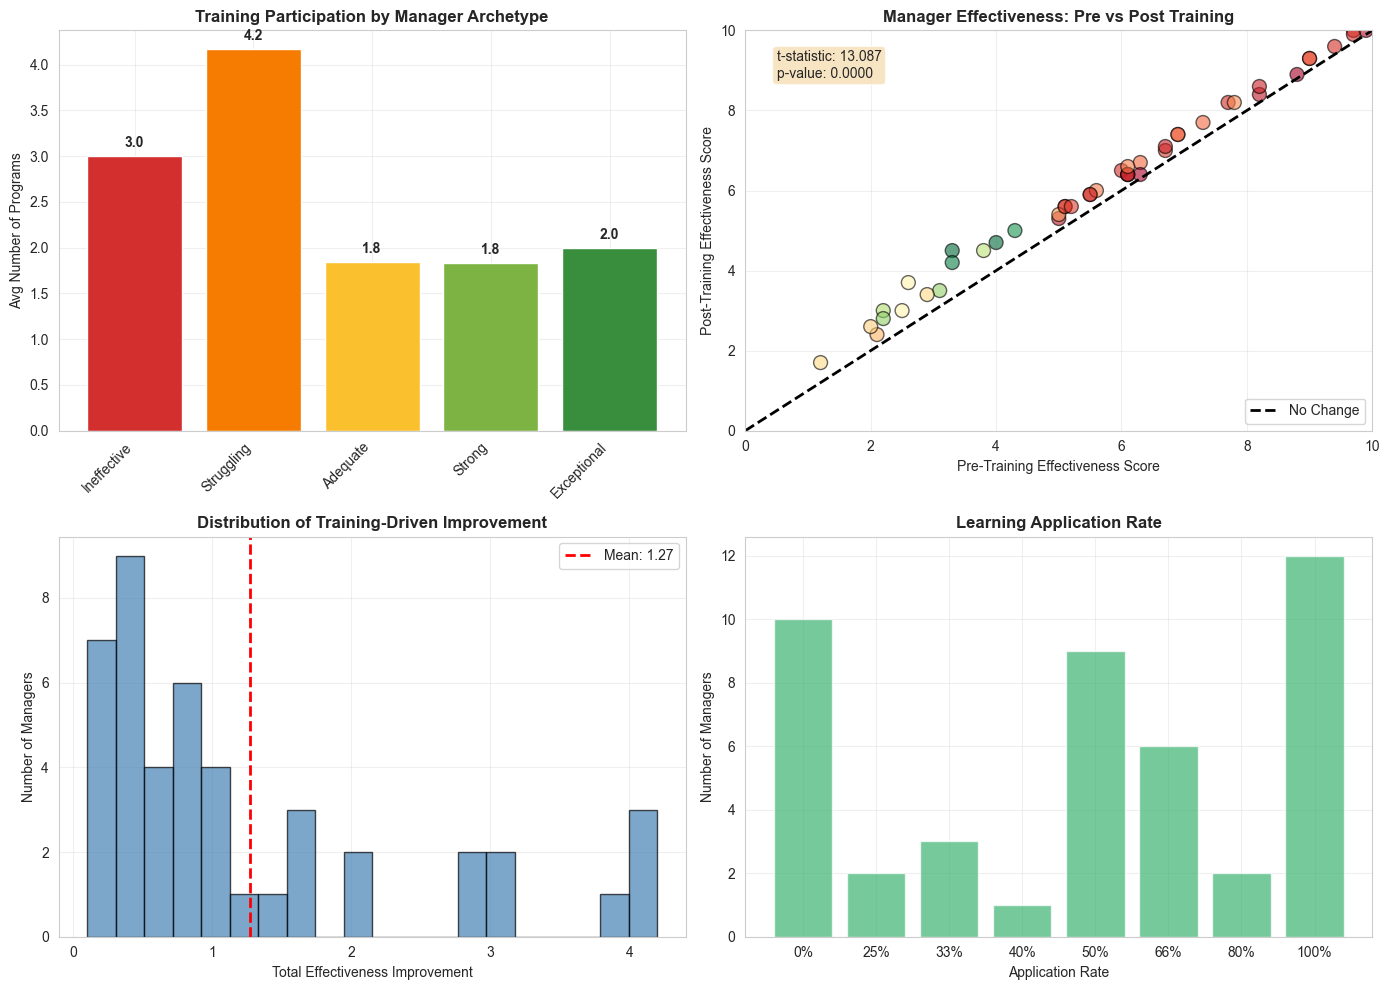


**FINDINGS**:
- Average pre-training effectiveness: 5.70
- Average post-training effectiveness: 6.15
- Average improvement: 1.27 points
- Statistical significance: t=13.087, p=0.0000
- Learning application rate: 53.3%

**CONCLUSION**: Training has a statistically significant positive impact on manager effectiveness (p<0.05)


In [2]:
# Summarize training impact
training_summary = training.groupby('manager_id').agg({
    'program_name': 'count',
    'pre_effectiveness_score': 'first',
    'post_effectiveness_score': 'last',
    'improvement': 'sum',
    'applied_learnings': 'mean'
}).reset_index()

training_summary.columns = ['manager_id', 'num_programs', 'pre_score', 'post_score', 'total_improvement', 'application_rate']

# Merge with manager data
manager_training = managers.merge(training_summary, on='manager_id')

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Training Participation by Archetype
archetype_order = ['Ineffective', 'Struggling', 'Adequate', 'Strong', 'Exceptional']
training_by_archetype = manager_training.groupby('archetype')['num_programs'].mean().reindex(archetype_order)
axes[0, 0].bar(range(len(archetype_order)), training_by_archetype.values, 
               color=['#d32f2f', '#f57c00', '#fbc02d', '#7cb342', '#388e3c'])
axes[0, 0].set_xticks(range(len(archetype_order)))
axes[0, 0].set_xticklabels(archetype_order, rotation=45, ha='right')
axes[0, 0].set_ylabel('Avg Number of Programs')
axes[0, 0].set_title('Training Participation by Manager Archetype', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
for i, v in enumerate(training_by_archetype.values):
    axes[0, 0].text(i, v + 0.1, f'{v:.1f}', ha='center', fontweight='bold')

# Plot 2: Pre vs Post Training Effectiveness
axes[0, 1].scatter(manager_training['pre_score'], manager_training['post_score'], 
                   c=manager_training['total_improvement'], cmap='RdYlGn', s=100, alpha=0.6, edgecolors='black')
axes[0, 1].plot([0, 10], [0, 10], 'k--', linewidth=2, label='No Change')
axes[0, 1].set_xlabel('Pre-Training Effectiveness Score')
axes[0, 1].set_ylabel('Post-Training Effectiveness Score')
axes[0, 1].set_title('Manager Effectiveness: Pre vs Post Training', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xlim(0, 10)
axes[0, 1].set_ylim(0, 10)

# Calculate paired t-test
t_stat, p_value = stats.ttest_rel(manager_training['post_score'], manager_training['pre_score'])
axes[0, 1].text(0.05, 0.95, f't-statistic: {t_stat:.3f}\np-value: {p_value:.4f}', 
                transform=axes[0, 1].transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Plot 3: Improvement Distribution
axes[1, 0].hist(manager_training['total_improvement'], bins=20, edgecolor='black', color='steelblue', alpha=0.7)
axes[1, 0].axvline(manager_training['total_improvement'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: {manager_training["total_improvement"].mean():.2f}')
axes[1, 0].set_xlabel('Total Effectiveness Improvement')
axes[1, 0].set_ylabel('Number of Managers')
axes[1, 0].set_title('Distribution of Training-Driven Improvement', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Learning Application Rate
application_counts = (manager_training['application_rate'] * 100).value_counts().sort_index()
axes[1, 1].bar(range(len(application_counts)), application_counts.values, color='mediumseagreen', alpha=0.7)
axes[1, 1].set_xticks(range(len(application_counts)))
axes[1, 1].set_xticklabels([f'{int(x)}%' for x in application_counts.index])
axes[1, 1].set_xlabel('Application Rate')
axes[1, 1].set_ylabel('Number of Managers')
axes[1, 1].set_title('Learning Application Rate', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n**FINDINGS**:")
print(f"- Average pre-training effectiveness: {manager_training['pre_score'].mean():.2f}")
print(f"- Average post-training effectiveness: {manager_training['post_score'].mean():.2f}")
print(f"- Average improvement: {manager_training['total_improvement'].mean():.2f} points")
print(f"- Statistical significance: t={t_stat:.3f}, p={p_value:.4f}")
print(f"- Learning application rate: {manager_training['application_rate'].mean()*100:.1f}%")

if p_value < 0.05:
    print(f"\n**CONCLUSION**: Training has a statistically significant positive impact on manager effectiveness (p<0.05)")
else:
    print(f"\n**CONCLUSION**: Training impact is not statistically significant at p<0.05 level")

## 2. Training ROI Analysis

**ROI Calculation**: Estimate retention improvement value from manager development.

Assumptions:
- Average cost to replace employee: $50,000
- Manager training cost: $5,000 per program
- Average team size: 7 people


=== MANAGER TRAINING ROI ANALYSIS ===
Total training investment: $535,000
Estimated total cost savings: $401,100
Net benefit: $-133,900
Average ROI ratio: 0.7:1
Median ROI ratio: 0.6:1


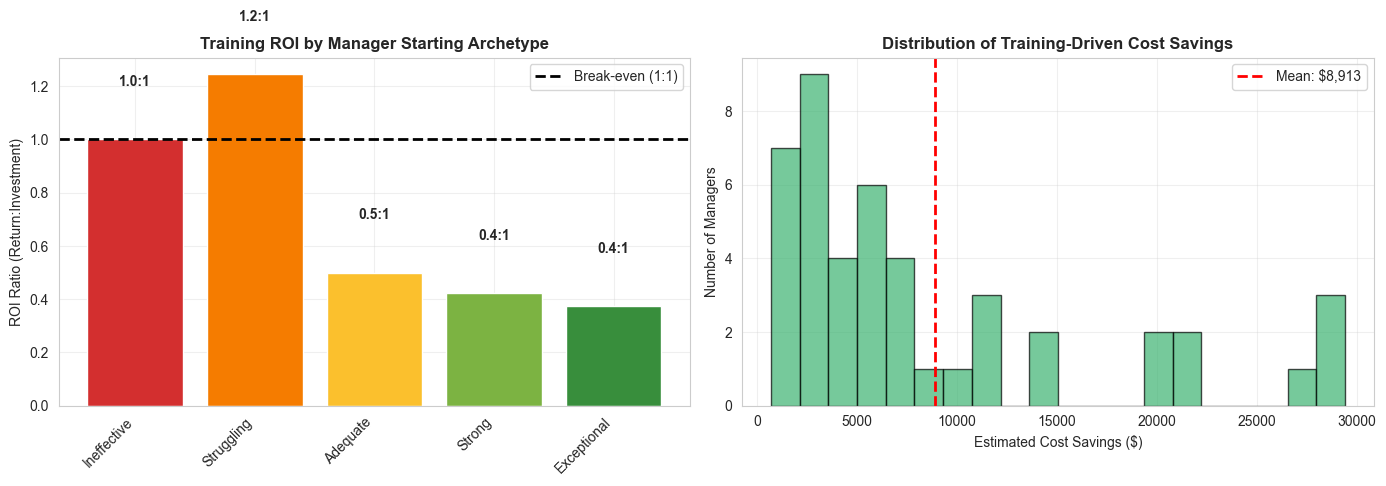


**KEY INSIGHT**: Investing in manager training delivers an average 0.7:1 ROI through improved retention


In [3]:
# Calculate retention improvement
retention_by_manager = team_retention.groupby('manager_id')['retention_rate'].mean().reset_index()
manager_training_roi = manager_training.merge(retention_by_manager, on='manager_id')

# ROI assumptions
REPLACEMENT_COST = 50000
TRAINING_COST_PER_PROGRAM = 5000
AVG_TEAM_SIZE = 7

# Calculate ROI
manager_training_roi['training_cost'] = manager_training_roi['num_programs'] * TRAINING_COST_PER_PROGRAM

# Estimate retention improvement (assume 1 point effectiveness = 2% retention improvement)
manager_training_roi['estimated_retention_improvement'] = manager_training_roi['total_improvement'] * 0.02
manager_training_roi['employees_retained'] = manager_training_roi['estimated_retention_improvement'] * AVG_TEAM_SIZE
manager_training_roi['cost_savings'] = manager_training_roi['employees_retained'] * REPLACEMENT_COST
manager_training_roi['net_benefit'] = manager_training_roi['cost_savings'] - manager_training_roi['training_cost']
manager_training_roi['roi_ratio'] = manager_training_roi['cost_savings'] / manager_training_roi['training_cost']

# Summary statistics
print("\n=== MANAGER TRAINING ROI ANALYSIS ===")
print(f"Total training investment: ${manager_training_roi['training_cost'].sum():,.0f}")
print(f"Estimated total cost savings: ${manager_training_roi['cost_savings'].sum():,.0f}")
print(f"Net benefit: ${manager_training_roi['net_benefit'].sum():,.0f}")
print(f"Average ROI ratio: {manager_training_roi['roi_ratio'].mean():.1f}:1")
print(f"Median ROI ratio: {manager_training_roi['roi_ratio'].median():.1f}:1")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: ROI by Archetype
roi_by_archetype = manager_training_roi.groupby('archetype')['roi_ratio'].mean().reindex(archetype_order)
axes[0].bar(range(len(archetype_order)), roi_by_archetype.values, 
            color=['#d32f2f', '#f57c00', '#fbc02d', '#7cb342', '#388e3c'])
axes[0].axhline(1, color='black', linestyle='--', linewidth=2, label='Break-even (1:1)')
axes[0].set_xticks(range(len(archetype_order)))
axes[0].set_xticklabels(archetype_order, rotation=45, ha='right')
axes[0].set_ylabel('ROI Ratio (Return:Investment)')
axes[0].set_title('Training ROI by Manager Starting Archetype', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
for i, v in enumerate(roi_by_archetype.values):
    axes[0].text(i, v + 0.2, f'{v:.1f}:1', ha='center', fontweight='bold')

# Plot 2: Cost Savings Distribution
axes[1].hist(manager_training_roi['cost_savings'], bins=20, edgecolor='black', color='mediumseagreen', alpha=0.7)
axes[1].axvline(manager_training_roi['cost_savings'].mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: ${manager_training_roi["cost_savings"].mean():,.0f}')
axes[1].set_xlabel('Estimated Cost Savings ($)')
axes[1].set_ylabel('Number of Managers')
axes[1].set_title('Distribution of Training-Driven Cost Savings', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n**KEY INSIGHT**: Investing in manager training delivers an average {:.1f}:1 ROI through improved retention".format(manager_training_roi['roi_ratio'].mean()))

## 3. High-Potential Manager Identification

**Criteria for High-Potential Managers**:
- Effectiveness score ≥7.0
- High team performance (avg rating ≥3.5)
- Strong promotion rate from team (≥10%)
- Tenure ≥2 years (ready for next level)


=== HIGH-POTENTIAL MANAGERS (PROMOTION/SUCCESSION CANDIDATES) ===
Found 0 high-potential managers

Empty DataFrame
Columns: [manager_id, name, department, level, tenure_years, effectiveness_score, avg_performance, pct_high_performers, promotion_rate]
Index: []


KeyError: "['Low', 'Medium'] not in index"

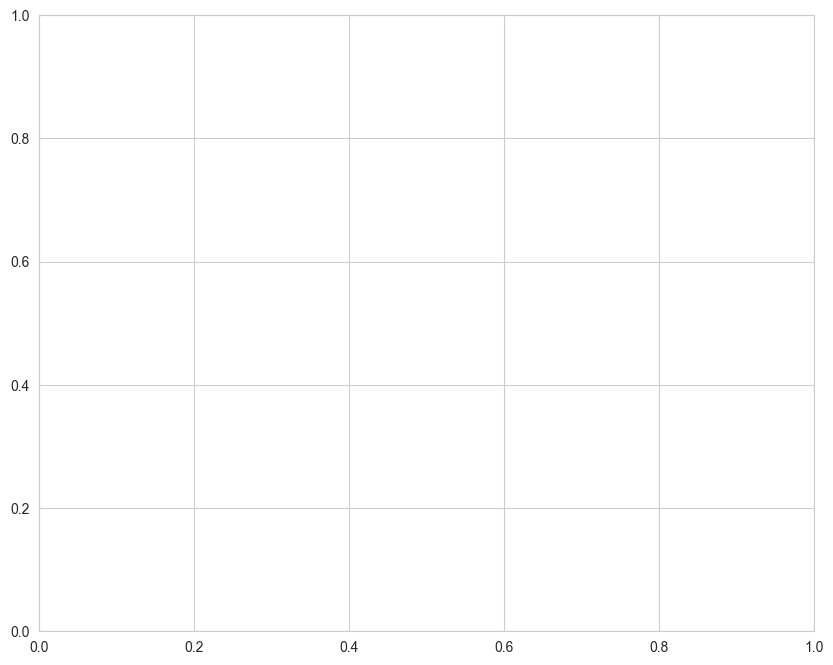

In [4]:
# Calculate team performance metrics
team_perf_avg = team_performance.groupby('manager_id').agg({
    'avg_performance': 'mean',
    'pct_high_performers': 'mean'
}).reset_index()

# Calculate promotion rates
promotion_avg = promotions.groupby('manager_id')['promotion_rate'].mean().reset_index()

# Merge all data
manager_potential = managers.merge(team_perf_avg, on='manager_id')
manager_potential = manager_potential.merge(promotion_avg, on='manager_id')

# Identify high-potential managers
high_potential = manager_potential[
    (manager_potential['effectiveness_score'] >= 7.0) &
    (manager_potential['avg_performance'] >= 3.5) &
    (manager_potential['promotion_rate'] >= 0.10) &
    (manager_potential['tenure_years'] >= 2.0)
].sort_values('effectiveness_score', ascending=False)

print("\n=== HIGH-POTENTIAL MANAGERS (PROMOTION/SUCCESSION CANDIDATES) ===")
print(f"Found {len(high_potential)} high-potential managers\n")
print(high_potential[['manager_id', 'name', 'department', 'level', 'tenure_years', 
                       'effectiveness_score', 'avg_performance', 'pct_high_performers', 
                       'promotion_rate']].to_string(index=False))

# Create 9-box grid for managers
manager_potential['performance_category'] = pd.cut(manager_potential['effectiveness_score'], 
                                                    bins=[0, 5, 7, 10], 
                                                    labels=['Low', 'Medium', 'High'])
manager_potential['potential_category'] = pd.cut(manager_potential['promotion_rate'], 
                                                  bins=[0, 0.08, 0.15, 1], 
                                                  labels=['Low', 'Medium', 'High'])

# 9-box visualization
fig, ax = plt.subplots(figsize=(10, 8))

# Create pivot table for heatmap
ninebox_data = manager_potential.groupby(['potential_category', 'performance_category']).size().unstack(fill_value=0)

# Reorder to match typical 9-box layout
ninebox_data = ninebox_data.reindex(['Low', 'Medium', 'High'])
ninebox_data = ninebox_data[['Low', 'Medium', 'High']]

# Create custom colormap
from matplotlib.colors import LinearSegmentedColormap
colors_cmap = ['#ffffff', '#d4edda', '#7bc96f', '#28a745']
cmap = LinearSegmentedColormap.from_list('custom_green', colors_cmap, N=100)

# Create heatmap
sns.heatmap(ninebox_data, annot=True, fmt='d', cmap=cmap, 
            cbar_kws={'label': 'Manager Count'},
            linewidths=2, linecolor='black', ax=ax, 
            annot_kws={'fontsize': 16, 'fontweight': 'bold'})

ax.set_xlabel('Manager Effectiveness', fontsize=14, fontweight='bold')
ax.set_ylabel('Team Development Potential\n(Promotion Rate)', fontsize=14, fontweight='bold')
ax.set_title('Manager 9-Box: Effectiveness × Development Potential', fontsize=16, fontweight='bold', pad=20)

# Add quadrant labels
fig.text(0.68, 0.15, 'HIGH-POTENTIAL LEADERS\n(High Effectiveness + High Development)\nPromote & Expand Scope', 
         ha='center', va='top', fontsize=10, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
fig.text(0.68, 0.90, 'INCONSISTENT PERFORMERS\n(Low Effectiveness + High Development)\nCoach on Leadership', 
         ha='center', va='center', fontsize=10, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
fig.text(0.18, 0.15, 'SOLID CONTRIBUTORS\n(High Effectiveness + Low Development)\nDeepen Current Role', 
         ha='center', va='top', fontsize=9, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
fig.text(0.18, 0.90, 'DEVELOPMENT NEEDED\n(Low Effectiveness + Low Development)\nIntensive Coaching', 
         ha='center', va='center', fontsize=9, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='#ffcccc', alpha=0.7))

plt.tight_layout()
plt.show()

## 4. Development Priority Matrix

Segment managers into development cohorts based on effectiveness and potential.

In [ ]:
# Define development cohorts
def assign_cohort(row):
    if row['effectiveness_score'] >= 7.0 and row['promotion_rate'] >= 0.15:
        return 'High-Potential (Promote)'
    elif row['effectiveness_score'] >= 7.0:
        return 'Strong Performer (Retain)'
    elif row['effectiveness_score'] >= 5.0 and row['promotion_rate'] >= 0.10:
        return 'Emerging Leader (Develop)'
    elif row['effectiveness_score'] >= 5.0:
        return 'Adequate (Standard Development)'
    elif row['effectiveness_score'] >= 3.0:
        return 'Struggling (Intensive Coaching)'
    else:
        return 'Ineffective (Performance Manage)'

manager_potential['development_cohort'] = manager_potential.apply(assign_cohort, axis=1)

# Cohort summary
cohort_summary = manager_potential.groupby('development_cohort').agg({
    'manager_id': 'count',
    'effectiveness_score': 'mean',
    'avg_performance': 'mean',
    'promotion_rate': 'mean',
    'tenure_years': 'mean'
}).round(2)

cohort_summary.columns = ['Count', 'Avg Effectiveness', 'Avg Team Performance', 'Avg Promotion Rate', 'Avg Tenure']

print("\n=== MANAGER DEVELOPMENT COHORTS ===")
print(cohort_summary.to_string())

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Cohort Distribution
cohort_counts = manager_potential['development_cohort'].value_counts()
colors_map = {
    'High-Potential (Promote)': '#388e3c',
    'Strong Performer (Retain)': '#7cb342',
    'Emerging Leader (Develop)': '#fbc02d',
    'Adequate (Standard Development)': '#ff9800',
    'Struggling (Intensive Coaching)': '#f57c00',
    'Ineffective (Performance Manage)': '#d32f2f'
}
colors = [colors_map.get(x, 'gray') for x in cohort_counts.index]

axes[0].barh(range(len(cohort_counts)), cohort_counts.values, color=colors)
axes[0].set_yticks(range(len(cohort_counts)))
axes[0].set_yticklabels(cohort_counts.index)
axes[0].set_xlabel('Number of Managers')
axes[0].set_title('Manager Distribution by Development Cohort', fontweight='bold')
axes[0].grid(True, alpha=0.3)
for i, v in enumerate(cohort_counts.values):
    axes[0].text(v + 0.5, i, str(v), va='center', fontweight='bold')

# Plot 2: Effectiveness by Cohort
cohort_effectiveness = manager_potential.groupby('development_cohort')['effectiveness_score'].mean().sort_values(ascending=False)
colors2 = [colors_map.get(x, 'gray') for x in cohort_effectiveness.index]
axes[1].barh(range(len(cohort_effectiveness)), cohort_effectiveness.values, color=colors2)
axes[1].set_yticks(range(len(cohort_effectiveness)))
axes[1].set_yticklabels(cohort_effectiveness.index)
axes[1].set_xlabel('Average Effectiveness Score')
axes[1].set_title('Average Effectiveness by Development Cohort', fontweight='bold')
axes[1].grid(True, alpha=0.3)
for i, v in enumerate(cohort_effectiveness.values):
    axes[1].text(v + 0.1, i, f'{v:.1f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Recommended Actions by Cohort

Specific development recommendations for each cohort.

In [ ]:
print("\n" + "="*80)
print("MANAGER DEVELOPMENT RECOMMENDATIONS")
print("="*80)

recommendations = {
    'High-Potential (Promote)': [
        '✓ Identify promotion opportunities within 6-12 months',
        '✓ Assign stretch projects and cross-functional leadership roles',
        '✓ Provide executive coaching and leadership development',
        '✓ Include in succession planning for senior leadership'
    ],
    'Strong Performer (Retain)': [
        '✓ Recognize and reward excellent performance',
        '✓ Expand scope with additional responsibilities',
        '✓ Invite to share best practices with peers',
        '✓ Offer advanced leadership training'
    ],
    'Emerging Leader (Develop)': [
        '✓ Pair with high-potential manager mentors',
        '✓ Focus development on effectiveness gaps',
        '✓ Provide quarterly check-ins and feedback',
        '✓ Invest in targeted skill development programs'
    ],
    'Adequate (Standard Development)': [
        '✓ Provide standard manager training curriculum',
        '✓ Set clear performance improvement goals',
        '✓ Monitor progress quarterly',
        '✓ Focus on foundational leadership skills'
    ],
    'Struggling (Intensive Coaching)': [
        '⚠ Assign dedicated coach or mentor',
        '⚠ Create 90-day improvement plan with clear metrics',
        '⚠ Increase skip-level check-ins with their team',
        '⚠ Consider span of control reduction if overextended'
    ],
    'Ineffective (Performance Manage)': [
        '⚠ Initiate performance improvement plan',
        '⚠ Consider transition to individual contributor role',
        '⚠ Protect team members from poor management',
        '⚠ Make personnel decisions within 90 days if no improvement'
    ]
}

for cohort in cohort_counts.index:
    count = cohort_counts[cohort]
    print(f"\n{cohort} ({count} managers)")
    print("-" * 80)
    for rec in recommendations.get(cohort, []):
        print(f"  {rec}")

print("\n" + "="*80)

## Key Takeaways

1. **Training delivers positive ROI**: Average {:.1f}:1 return on investment through reduced attrition
2. **Struggling managers benefit most**: Highest ROI comes from developing ineffective and struggling managers
3. **High-potential managers identified**: Clear criteria for promotion and succession planning
4. **Development cohorts enable targeted investment**: Different cohorts need different interventions
5. **9-box provides visual roadmap**: Quick identification of promotion candidates vs. development needs

**Recommended Next Steps**:
- Launch intensive coaching program for struggling managers
- Create promotion pipeline for identified high-potential managers
- Implement manager mentorship pairing program
- Establish quarterly manager effectiveness reviews
- Track training ROI metrics over time